In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
# tab_gid = "908803302"
tab_gid = "1990888583" 
limit = 15
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=['Model', 'Compression', 'Size (MB)', 'BLEU']).iloc[:limit, :]
df

,Model,Compression,Size (MB),BLEU
0,pythia-70M,Original,281.73,42.00
1,pythia-70M,8-bit,122.13,41.39
2,pythia-70M,4-bit,113.77,39.21
3,pythia-160M,Original,649.34,42.49
4,pythia-160M,8-bit,240.12,42.31
5,pythia-160M,4-bit,202.65,40.60
6,pythia-410M,Original,1621.43,43.51
7,pythia-410M,8-bit,509.70,43.61
8,pythia-410M,4-bit,376.75,42.41
9,pythia-1B,Original,4047.19,44.18


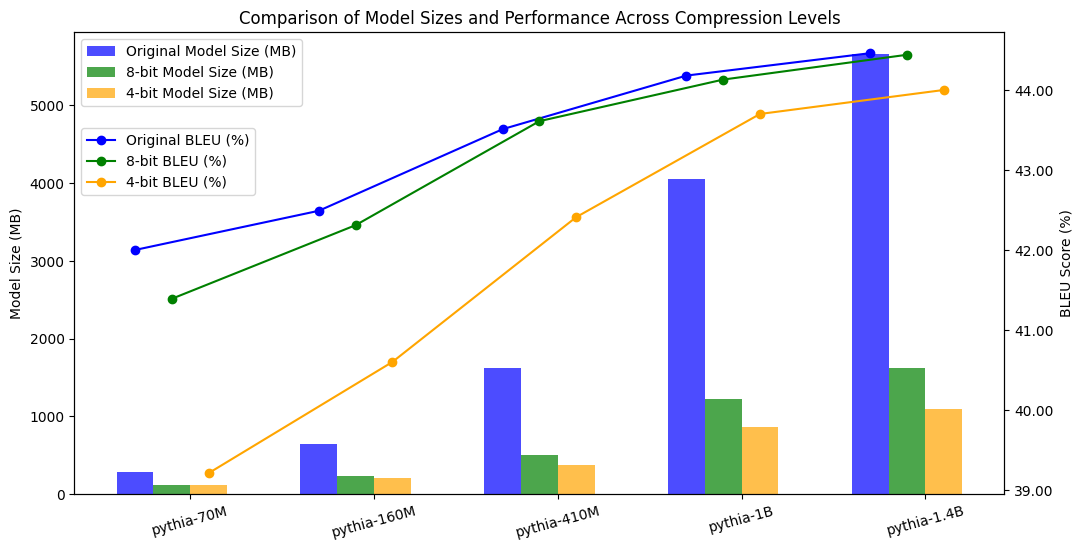

In [5]:

# Extract unique model names
models = df["Model"].unique()
compressions = df["Compression"].unique()

# Define bar width and colors
bar_width = 0.2
colors = ["blue", "green", "orange"]

x = np.arange(len(models))  # X-axis positions

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bar chart for model sizes
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    ax1.bar(x + i * bar_width, subset["Size (MB)"], width=bar_width, label=f"{comp} Model Size (MB)", alpha=0.7, color=colors[i])

ax1.set_ylabel("Model Size (MB)")
ax1.set_xticks(x + bar_width * 1.5)
ax1.set_xticklabels(models, rotation=15)
ax1.legend(loc="upper left")

# Second y-axis for performance scores
ax2 = ax1.twinx()

# Plot line chart for performance
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    ax2.plot(x + i * bar_width, subset["BLEU"], marker="o", linestyle="-", label=f"{comp} BLEU (%)", color=colors[i])

ax2.set_ylabel("BLEU Score (%)")
ax2.legend(loc="center left", bbox_to_anchor=(0, 0.72))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))

plt.title("Comparison of Model Sizes and Performance Across Compression Levels")
plt.savefig(f"./output/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
df = pd.read_csv(full_url, skiprows=2, usecols=['Model', 'Compression', 'Size (MB)', 'ROC_AUC', 'PR_AUC', 'ROC_AUC.1', 'PR_AUC.1', 'ROC_AUC.2', 'PR_AUC.2', 'ROC_AUC.3', 'PR_AUC.3']).iloc[:limit, :]
df


,Model,Compression,Size (MB),ROC_AUC,PR_AUC,ROC_AUC.1,PR_AUC.1,ROC_AUC.2,PR_AUC.2,ROC_AUC.3,PR_AUC.3
0,pythia-70M,Original,281.73,64.55,60.87,64.91,61.32,66.51,62.86,61.87,56.28
1,pythia-70M,8-bit,122.13,64.53,60.86,64.80,61.20,66.49,62.87,61.86,56.32
2,pythia-70M,4-bit,113.77,63.36,60.44,63.21,60.40,65.66,62.54,58.66,54.29
3,pythia-160M,Original,649.34,65.70,61.64,65.59,61.57,67.44,63.55,63.95,58.17
4,pythia-160M,8-bit,240.12,65.66,61.57,65.52,61.46,67.41,63.50,63.82,58.10
5,pythia-160M,4-bit,202.65,64.50,61.12,64.19,60.90,66.68,63.27,59.69,55.09
6,pythia-410M,Original,1621.43,67.41,62.69,67.52,62.66,68.87,64.42,67.11,61.24
7,pythia-410M,8-bit,509.70,67.40,62.69,67.50,62.67,68.86,64.40,67.13,61.23
8,pythia-410M,4-bit,376.75,65.67,61.91,65.96,61.92,67.73,63.88,60.39,55.77
9,pythia-1B,Original,4047.19,68.99,63.86,69.07,63.93,70.29,65.54,68.34,63.68


In [12]:
def genGraph(df, miaName):
    scoreName = df.columns[3].split(".")[0]
    # Extract unique model names
    models = df["Model"].unique()
    compressions = df["Compression"].unique()

    # Define bar width and colors
    bar_width = 0.2
    colors = ["blue", "green", "orange"]

    x = np.arange(len(models))  # X-axis positions

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot bar chart for model sizes
    for i, comp in enumerate(compressions):
        subset = df[df["Compression"] == comp]
        ax1.bar(x + i * bar_width, subset["Size (MB)"], width=bar_width, label=f"{comp} Model Size (MB)", alpha=0.7, color=colors[i])

    ax1.set_ylabel("Model Size (MB)")
    ax1.set_xticks(x + bar_width * 1.5)
    ax1.set_xticklabels(models, rotation=15)
    ax1.legend(loc="upper left")

    # Second y-axis for performance scores
    ax2 = ax1.twinx()

    # Plot line chart for performance
    for i, comp in enumerate(compressions):
        subset = df[df["Compression"] == comp]
        ax2.plot(x + i * bar_width, subset.iloc[:,3], marker="o", linestyle="-", label=f"{comp} {scoreName} ({miaName}) (%)", color=colors[i])

    ax2.set_ylabel(f"{scoreName} ({miaName}) (%)")
    # ax2.set_ylim(0.6, 0.7)
    ax2.legend(loc="center left", bbox_to_anchor=(0, 0.7))
    # ax2.legend(loc="upper right")
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))


    plt.title(f"Comparison of Model Sizes and MIA ({miaName}) Across Compression Levels")
    plt.savefig(f"./output/{scoreName}({miaName}).png", dpi=300, bbox_inches="tight")
    plt.show()

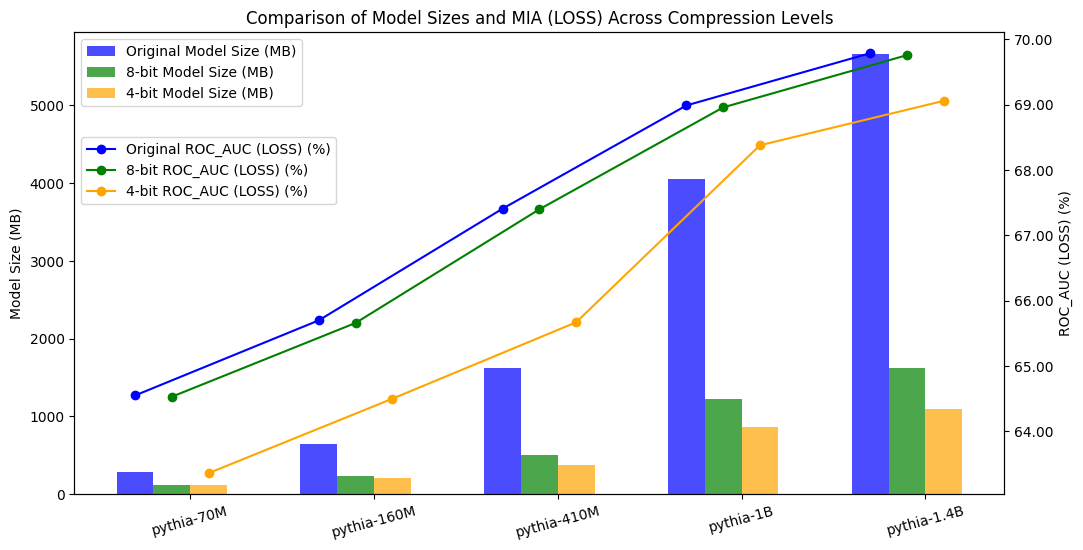

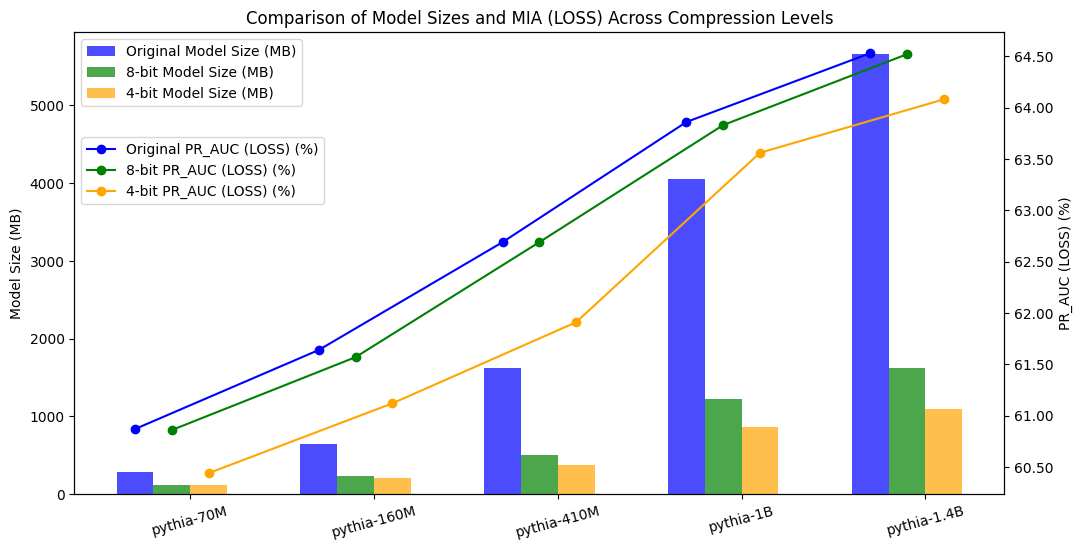

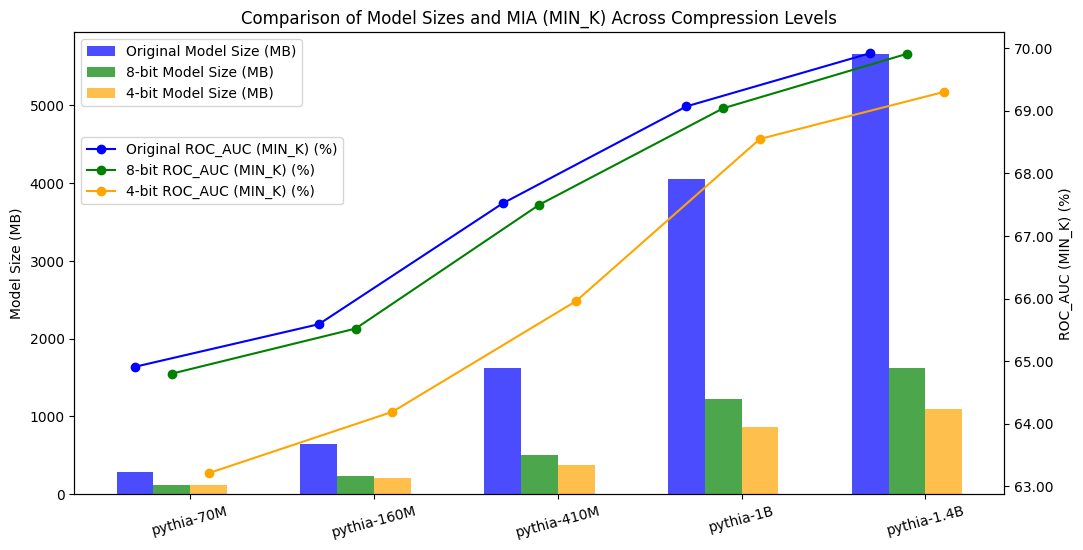

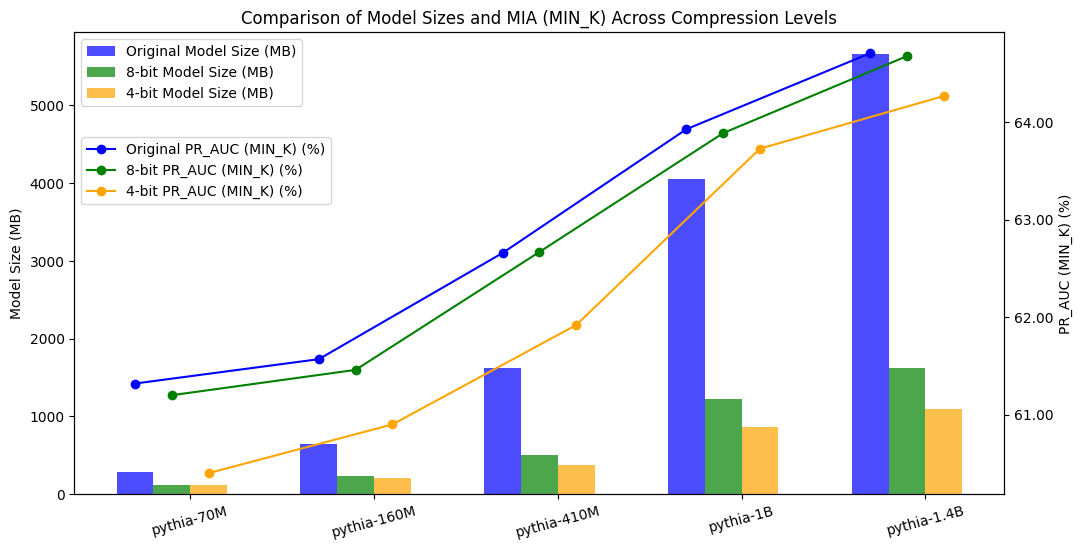

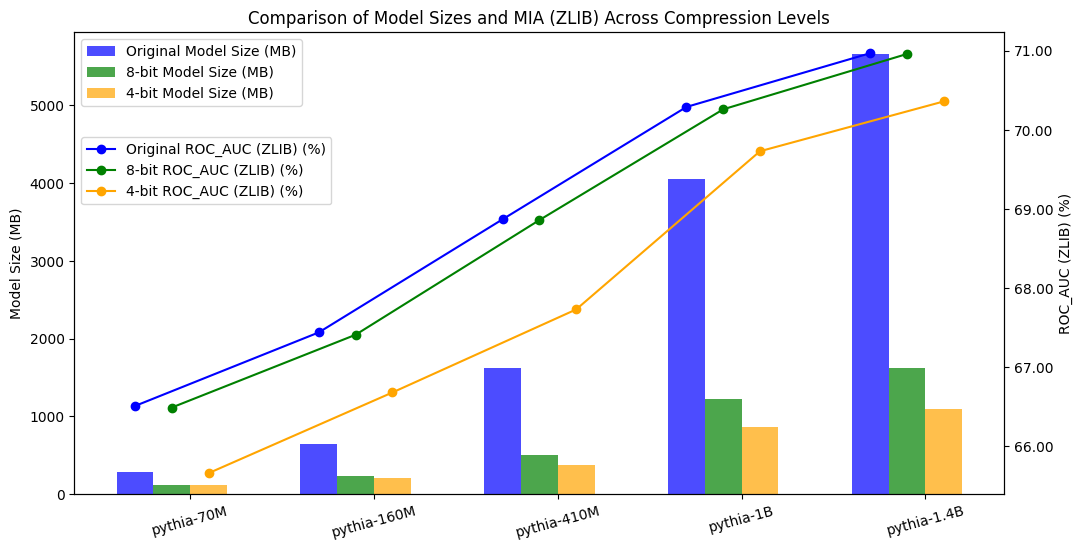

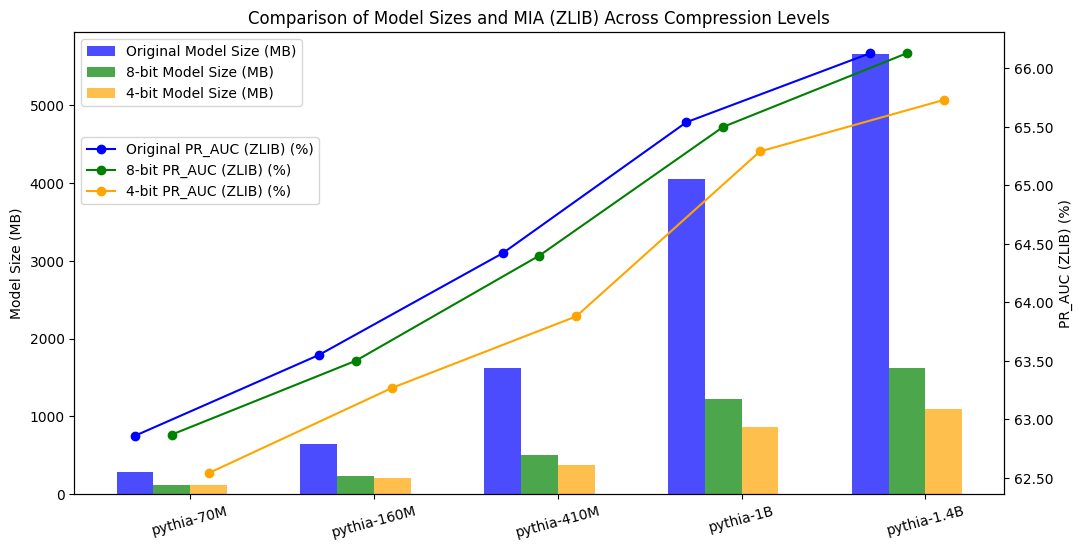

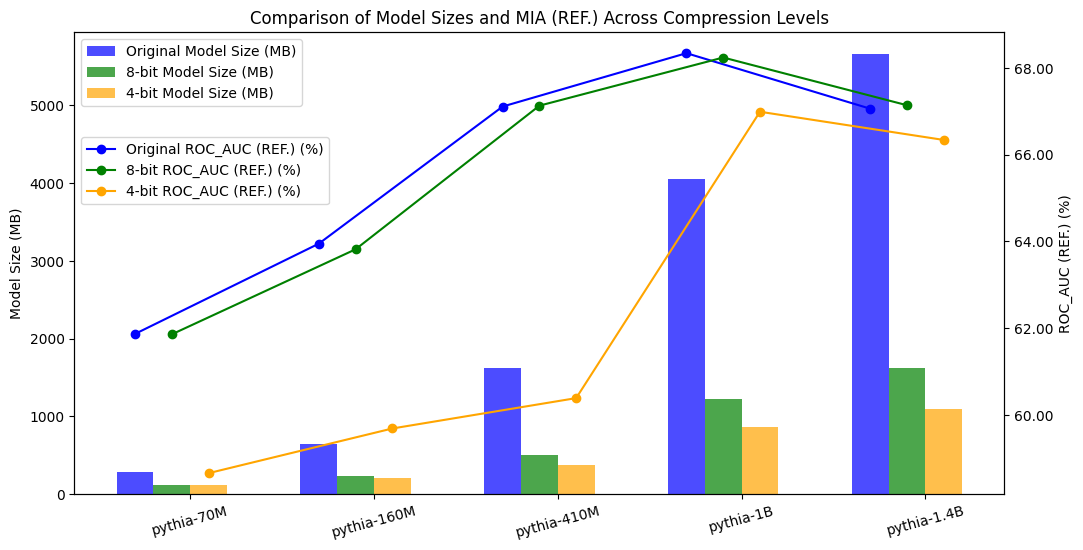

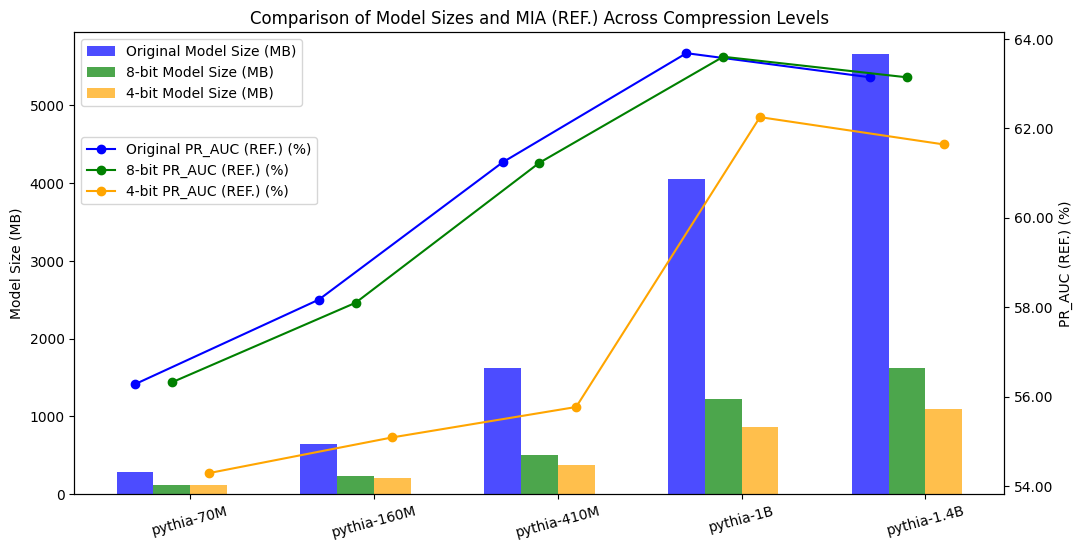

In [13]:
genGraph(df.iloc[:, [0,1,2,3]], miaName="LOSS")
genGraph(df.iloc[:, [0,1,2,4]], miaName="LOSS")
genGraph(df.iloc[:, [0,1,2,5]], miaName="MIN_K")
genGraph(df.iloc[:, [0,1,2,6]], miaName="MIN_K")
genGraph(df.iloc[:, [0,1,2,7]], miaName="ZLIB")
genGraph(df.iloc[:, [0,1,2,8]], miaName="ZLIB")
genGraph(df.iloc[:, [0,1,2,9]], miaName="REF.")
genGraph(df.iloc[:, [0,1,2,10]], miaName="REF.")

In [28]:
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU", "ROC_AUC.2"]).iloc[:limit, :]


/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_57925/927862420.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


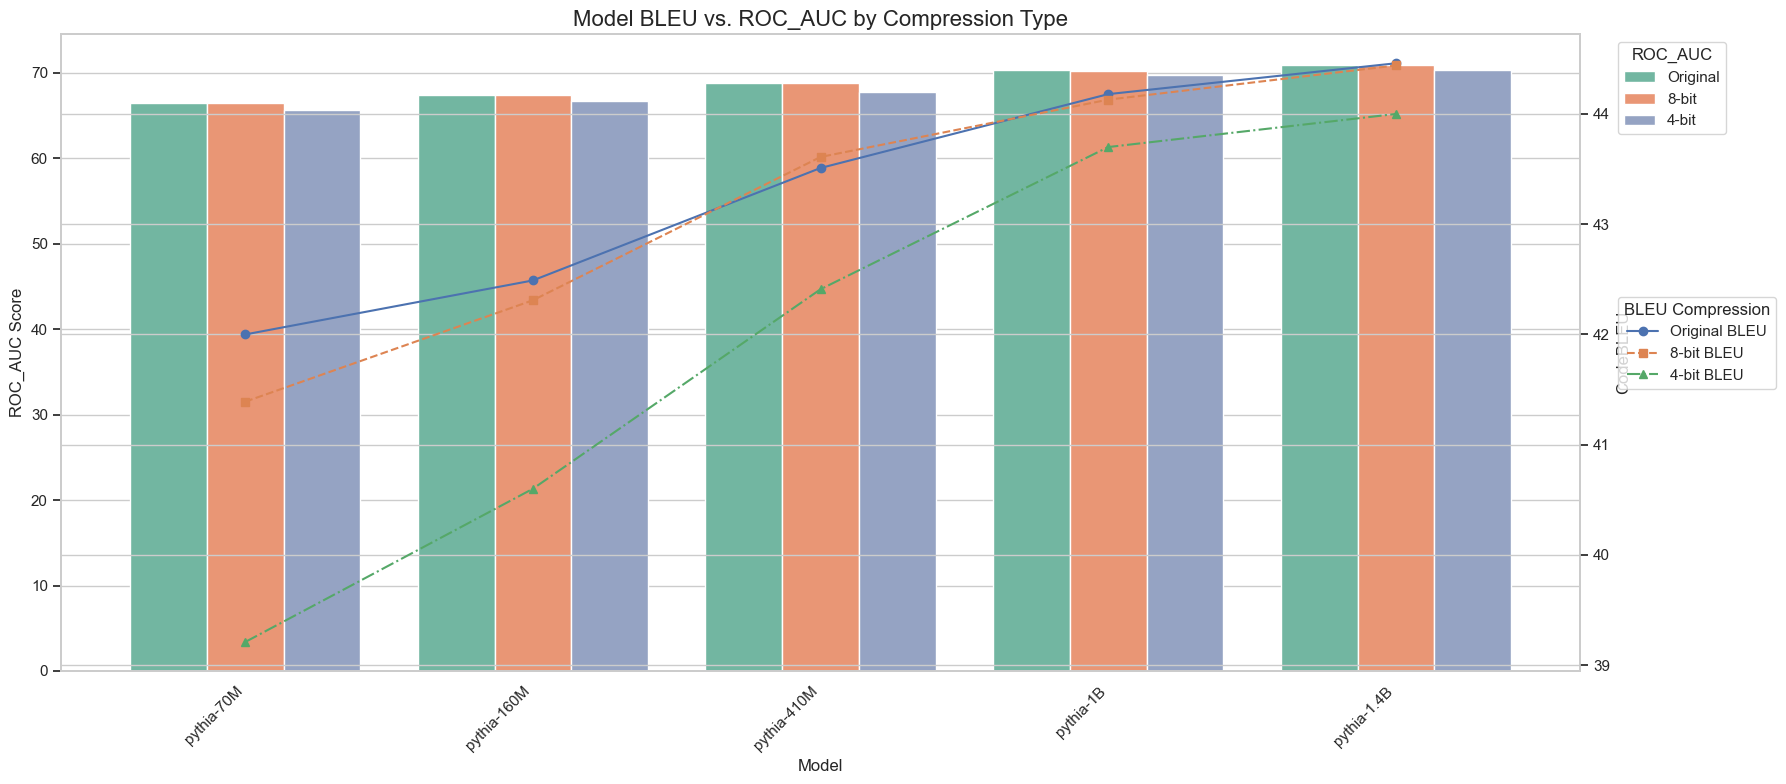

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plot
plt.figure(figsize=(18, 8))
sns.set(style="whitegrid")

# Barplot for BLEU
ax = sns.barplot(data=df, x="Model", y="ROC_AUC.2", hue="Compression", palette="Set2")

# Secondary axis for ROC_AUC
ax2 = ax.twinx()
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'v']
# Line plot for ROC_AUC
for i, compression in enumerate(df["Compression"].unique()):
    subset = df[df["Compression"] == compression]
    line_style = line_styles[i % len(line_styles)]
    marker = markers[i % len(markers)]
    ax2.plot(subset["Model"].values, subset["BLEU"].values, label=f"{compression} BLEU", linestyle=line_style, marker = marker)

# Formatting
ax.set_ylabel("ROC_AUC Score")
ax2.set_ylabel("CodeBLEU")
ax.set_title("Model BLEU vs. ROC_AUC by Compression Type", fontsize=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title="ROC_AUC")
ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 0.6), title="BLEU Compression")

plt.tight_layout()
plt.savefig("./output/MIAvsTask.png", dpi=300, bbox_inches="tight")

plt.show()